In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

stores = pd.read_csv(r"C:\Users\user\Desktop\stores.csv")
sales= pd.read_csv(r"C:\Users\user\Desktop\sales.csv")
products = pd.read_csv(r"C:\Users\user\Desktop\products.csv")
stores


,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online
...,...,...,...,...,...
95,S096,Chocolate Store 96,Berlin,UK,Mall
96,S097,Chocolate Store 97,Toronto,Canada,Mall
97,S098,Chocolate Store 98,New York,Australia,Online
98,S099,Chocolate Store 99,Toronto,Australia,Mall


In [ ]:
stores.head()
stores.info()
stores.describe
stores.shape

In [10]:
sales

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40
...,...,...,...,...,...,...,...,...,...,...,...
999995,0RD00999996,2023-04-15,P0103,S053,C044763,4,7.45,0.00,29.80,17.27,12.53
999996,0RD00999997,2023-05-26,P0094,S058,C004441,2,6.09,0.00,12.18,7.81,4.37
999997,0RD00999998,2023-07-05,P0097,S041,C044879,3,6.09,0.00,18.27,10.11,8.16
999998,0RD00999999,2024-01-03,P0090,S083,C042525,1,4.90,0.00,4.90,2.56,2.34


In [ ]:
sales.head()
sales.info()
sales.describe()
sales.shape

In [11]:
products

,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50
...,...,...,...,...,...,...
195,P0196,White Chocolate 60%,Mars,Praline,60,80
196,P0197,Truffle Chocolate 90%,Hershey,Truffle,90,120
197,P0198,Dark Chocolate 90%,Ferrero,White,90,80
198,P0199,Dark Chocolate 70%,Hershey,White,70,80


In [14]:
products.head()
products.info()
products.describe()
products.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     200 non-null    object
 1   product_name   200 non-null    object
 2   brand          200 non-null    object
 3   category       200 non-null    object
 4   cocoa_percent  200 non-null    int64 
 5   weight_g       200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB


(200, 6)

In [5]:
products.brand.value_counts()

brand
Cadbury    37
Ferrero    37
Lindt      35
Mars       33
Godiva     30
Hershey    28
Name: count, dtype: int64

In [6]:
for p in products.brand.value_counts():
    print(p)

37
37
35
33
30
28


In [7]:
products.category.unique()

array(['Truffle', 'Praline', 'White', 'Dark', 'Milk'], dtype=object)

In [24]:
{i+1: for product in (products['brand'].unique())}

SyntaxError: invalid syntax (30647785.py, line 1)

In [8]:
#label encoding for brand names
products['brand_id']= products.category.map({product: i+1 for i, product in enumerate(
    products['category'].unique())})
products

,product_id,product_name,brand,category,cocoa_percent,weight_g,brand_id
0,P0001,White Chocolate 80%,Mars,Truffle,80,120,1
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100,2
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120,2
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80,2
4,P0005,White Chocolate 70%,Ferrero,White,70,50,3
...,...,...,...,...,...,...,...
195,P0196,White Chocolate 60%,Mars,Praline,60,80,2
196,P0197,Truffle Chocolate 90%,Hershey,Truffle,90,120,1
197,P0198,Dark Chocolate 90%,Ferrero,White,90,80,3
198,P0199,Dark Chocolate 70%,Hershey,White,70,80,3


In [9]:
#changing product ID
products['new_product_id'] = products.product_id.apply(lambda x: int(x[1:]))
products

,product_id,product_name,brand,category,cocoa_percent,weight_g,brand_id,new_product_id
0,P0001,White Chocolate 80%,Mars,Truffle,80,120,1,1
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100,2,2
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120,2,3
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80,2,4
4,P0005,White Chocolate 70%,Ferrero,White,70,50,3,5
...,...,...,...,...,...,...,...,...
195,P0196,White Chocolate 60%,Mars,Praline,60,80,2,196
196,P0197,Truffle Chocolate 90%,Hershey,Truffle,90,120,1,197
197,P0198,Dark Chocolate 90%,Ferrero,White,90,80,3,198
198,P0199,Dark Chocolate 70%,Hershey,White,70,80,3,199


In [10]:
# joining products and sales data
main_data = pd.merge(sales, products)
main_data

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g,brand_id,new_product_id
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,Praline Chocolate 70%,Hershey,White,70,200,3,80
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,Dark Chocolate 60%,Lindt,Praline,60,50,2,173
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,Milk Chocolate 90%,Hershey,Milk,90,50,5,115
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,Dark Chocolate 60%,Godiva,Praline,60,50,2,186
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,Truffle Chocolate 90%,Hershey,Truffle,90,120,1,197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990231,0RD00999996,2023-04-15,P0103,S053,C044763,4,7.45,0.00,29.80,17.27,12.53,Praline Chocolate 50%,Ferrero,White,50,100,3,103
990232,0RD00999997,2023-05-26,P0094,S058,C004441,2,6.09,0.00,12.18,7.81,4.37,Dark Chocolate 50%,Ferrero,Dark,50,200,4,94
990233,0RD00999998,2023-07-05,P0097,S041,C044879,3,6.09,0.00,18.27,10.11,8.16,Milk Chocolate 80%,Godiva,Milk,80,50,5,97
990234,0RD00999999,2024-01-03,P0090,S083,C042525,1,4.90,0.00,4.90,2.56,2.34,Dark Chocolate 50%,Hershey,Praline,50,120,2,90


In [41]:
# Filter products and sales data
customer_records = main_data[main_data['customer_id'] == 'C044952']
customer_records.reset_index(inplace= True)

#Gettingnthe products bought by C044952
customer_products = customer_records.new_product_id.unique()
customer_records

,index,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g,brand_id,new_product_id
0,59311,0RD00059861,2023-07-21,P0143,S086,C044952,1,9.37,0.10,8.43,5.38,3.05,White Chocolate 90%,Godiva,Milk,90,50,5,143
1,99285,0RD00100243,2024-09-24,P0123,S060,C044952,4,3.76,0.20,12.03,7.22,4.81,Praline Chocolate 50%,Cadbury,White,50,50,3,123
2,99862,0RD00100823,2023-12-15,P0143,S095,C044952,3,12.57,0.00,37.71,23.35,14.36,White Chocolate 90%,Godiva,Milk,90,50,5,143
3,157211,0RD00158721,2023-04-29,P0150,S084,C044952,4,8.09,0.00,32.36,18.40,13.96,Milk Chocolate 50%,Hershey,Praline,50,100,2,150
4,214480,0RD00216583,2023-12-09,P0059,S062,C044952,2,5.46,0.00,10.92,6.61,4.31,Praline Chocolate 50%,Godiva,White,50,80,3,59
5,235126,0RD00237452,2024-03-26,P0113,S053,C044952,2,11.74,0.15,19.96,10.36,9.60,Truffle Chocolate 80%,Mars,White,80,50,3,113
6,249099,0RD00251569,2023-07-17,P0057,S029,C044952,3,7.03,0.00,21.09,11.58,9.51,Truffle Chocolate 90%,Cadbury,Milk,90,80,5,57
7,253202,0RD00255708,2024-04-23,P0160,S047,C044952,2,12.38,0.00,24.76,15.63,9.13,Praline Chocolate 90%,Hershey,Dark,90,100,4,160
8,277851,0RD00280590,2024-06-03,P0028,S070,C044952,1,5.42,0.00,5.42,3.03,2.39,Dark Chocolate 50%,Lindt,Dark,50,200,4,28
9,307958,0RD00310963,2024-10-21,P0152,S079,C044952,2,11.47,0.00,22.94,13.56,9.38,Milk Chocolate 70%,Lindt,Praline,70,200,2,152


In [12]:
product_profile = products.set_index('new_product_id')
product_profile.drop(['product_id', 'product_name','brand','category'],axis=1, inplace=True)
product_profile

,cocoa_percent,weight_g,brand_id
new_product_id,,,
1,80,120,1
2,70,100,2
3,70,120,2
4,50,80,2
5,70,50,3
...,...,...,...
196,60,80,2
197,90,120,1
198,90,80,3


In [49]:
customer_profile = product_profile.loc[customer_products].mean()
customer_profile

quantity           2.55000
unit_price         8.28100
discount           0.05875
revenue           19.64225
cost              12.01850
profit             7.62450
cocoa_percent     67.25000
weight_g         114.00000
brand_id           2.97500
brand_rank         3.25000
category_rank      2.72500
dtype: float64

In [42]:
#Ranking Brands by Frequency

brand_frequency = customer_records.brand.value_counts().reset_index()
brand_frequency.columns = ['brand', 'frequency']
brand_frequency['rank'] = brand_frequency['frequency'].rank(
    ascending= True, method= 'dense').astype(int)
brand_frequency

,brand,frequency,rank
0,Cadbury,10,5
1,Lindt,8,4
2,Ferrero,7,3
3,Godiva,6,2
4,Hershey,6,2
5,Mars,3,1


In [43]:
#Ranking category by Frequency

category_frequency = customer_records.category.value_counts().reset_index()
category_frequency.columns = ['category', 'frequency']
category_frequency['rank'] = category_frequency['frequency'].rank(
    ascending= True, method= 'dense').astype(int)
category_frequency

,category,frequency,rank
0,Praline,13,4
1,Dark,8,3
2,Milk,7,2
3,White,7,2
4,Truffle,5,1


In [44]:
##Adding Ranks to customer records

customer_records =  customer_records.merge(brand_frequency, on= 'brand')
customer_records =  customer_records.merge(category_frequency, on= 'category')

customer_records.drop(['frequency_x', 'frequency_y'], axis= 1, inplace= True)
customer_records.rename(columns= {'rank_x': 'brand_rank', 'rank_y': 'category_rank'}, inplace= True)
customer_records

,index,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,...,profit,product_name,brand,category,cocoa_percent,weight_g,brand_id,new_product_id,brand_rank,category_rank
0,59311,0RD00059861,2023-07-21,P0143,S086,C044952,1,9.37,0.10,8.43,...,3.05,White Chocolate 90%,Godiva,Milk,90,50,5,143,2,2
1,99285,0RD00100243,2024-09-24,P0123,S060,C044952,4,3.76,0.20,12.03,...,4.81,Praline Chocolate 50%,Cadbury,White,50,50,3,123,5,2
2,99862,0RD00100823,2023-12-15,P0143,S095,C044952,3,12.57,0.00,37.71,...,14.36,White Chocolate 90%,Godiva,Milk,90,50,5,143,2,2
3,157211,0RD00158721,2023-04-29,P0150,S084,C044952,4,8.09,0.00,32.36,...,13.96,Milk Chocolate 50%,Hershey,Praline,50,100,2,150,2,4
4,214480,0RD00216583,2023-12-09,P0059,S062,C044952,2,5.46,0.00,10.92,...,4.31,Praline Chocolate 50%,Godiva,White,50,80,3,59,2,2
5,235126,0RD00237452,2024-03-26,P0113,S053,C044952,2,11.74,0.15,19.96,...,9.60,Truffle Chocolate 80%,Mars,White,80,50,3,113,1,2
6,249099,0RD00251569,2023-07-17,P0057,S029,C044952,3,7.03,0.00,21.09,...,9.51,Truffle Chocolate 90%,Cadbury,Milk,90,80,5,57,5,2
7,253202,0RD00255708,2024-04-23,P0160,S047,C044952,2,12.38,0.00,24.76,...,9.13,Praline Chocolate 90%,Hershey,Dark,90,100,4,160,2,3
8,277851,0RD00280590,2024-06-03,P0028,S070,C044952,1,5.42,0.00,5.42,...,2.39,Dark Chocolate 50%,Lindt,Dark,50,200,4,28,4,3
9,307958,0RD00310963,2024-10-21,P0152,S079,C044952,2,11.47,0.00,22.94,...,9.38,Milk Chocolate 70%,Lindt,Praline,70,200,2,152,4,4


In [45]:
customer_records.columns

Index(['index', 'order_id', 'order_date', 'product_id', 'store_id',
       'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost',
       'profit', 'product_name', 'brand', 'category', 'cocoa_percent',
       'weight_g', 'brand_id', 'new_product_id', 'brand_rank',
       'category_rank'],
      dtype='object')

In [47]:
product_profile = customer_records.set_index('new_product_id')
product_profile= product_profile.select_dtypes(include= 'number')
del product_profile['index']
product_profile

,quantity,unit_price,discount,revenue,cost,profit,cocoa_percent,weight_g,brand_id,brand_rank,category_rank
new_product_id,,,,,,,,,,,
143,1,9.37,0.10,8.43,5.38,3.05,90,50,5,2,2
123,4,3.76,0.20,12.03,7.22,4.81,50,50,3,5,2
143,3,12.57,0.00,37.71,23.35,14.36,90,50,5,2,2
150,4,8.09,0.00,32.36,18.40,13.96,50,100,2,2,4
59,2,5.46,0.00,10.92,6.61,4.31,50,80,3,2,2
113,2,11.74,0.15,19.96,10.36,9.60,80,50,3,1,2
57,3,7.03,0.00,21.09,11.58,9.51,90,80,5,5,2
160,2,12.38,0.00,24.76,15.63,9.13,90,100,4,2,3
28,1,5.42,0.00,5.42,3.03,2.39,50,200,4,4,3


In [53]:
customer_profile = product_profile.loc[customer_products].mean()
customer_profile

quantity           2.550000
unit_price         8.281000
discount           0.058750
revenue           19.642250
cost              12.018500
profit             7.624500
cocoa_percent     67.250000
weight_g         114.000000
brand_id           2.975000
brand_rank         3.250000
category_rank      2.725000
score              0.956339
dtype: float64

In [54]:
#MEASURING SIMILARITY WITH ALL PRODUCTS
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(product_profile, customer_profile.values.reshape(1, -1))
scores

array([[0.86253401],
       [0.96751594],
       [0.84724396],
       [0.98470355],
       [0.99884374],
       [0.88923525],
       [0.95322217],
       [0.97966504],
       [0.94786131],
       [0.98000067],
       [0.96575192],
       [0.98122465],
       [0.97108997],
       [0.95245444],
       [0.98491201],
       [0.9831453 ],
       [0.96471724],
       [0.81712228],
       [0.97869993],
       [0.99335545],
       [0.94289035],
       [0.9662788 ],
       [0.98073892],
       [0.98777237],
       [0.973234  ],
       [0.95389883],
       [0.96719776],
       [0.97232313],
       [0.97952122],
       [0.95179653],
       [0.9589241 ],
       [0.87530225],
       [0.99546031],
       [0.98618481],
       [0.93164739],
       [0.99513071],
       [0.94766558],
       [0.96656699],
       [0.9403993 ],
       [0.97727234]])

In [59]:
#Recommending Top Products
product_profile['score'] = scores
recommendations = product_profile.sort_values('score', ascending= False)
products = products.set_index('new_product_id')
recommended_products =products.loc[recommendations.index]
print('Top 10 recommendations:')
recommended_products.head(10)

Top 10 recommendations:


,product_id,product_name,brand,category,cocoa_percent,weight_g,brand_id
new_product_id,,,,,,,
59,P0059,Praline Chocolate 50%,Godiva,White,50,80,3
23,P0023,Dark Chocolate 70%,Cadbury,Praline,70,100,2
185,P0185,Milk Chocolate 70%,Ferrero,Praline,70,100,2
139,P0139,Dark Chocolate 50%,Godiva,Praline,50,100,2
51,P0051,Milk Chocolate 80%,Lindt,Truffle,80,200,1
12,P0012,Truffle Chocolate 80%,Mars,Praline,80,200,2
77,P0077,Truffle Chocolate 70%,Cadbury,Praline,70,100,2
150,P0150,Milk Chocolate 50%,Hershey,Praline,50,100,2
188,P0188,Praline Chocolate 50%,Cadbury,Dark,50,120,4


In [57]:
print(recommendations.head(10))

                quantity  unit_price  discount  revenue   cost  profit  \
new_product_id                                                           
59                     2        5.46      0.00    10.92   6.61    4.31   
23                     4        5.78      0.00    23.12  14.87    8.25   
185                    2       12.63      0.10    22.73  15.07    7.66   
139                    2       12.21      0.00    24.42  14.32   10.10   
51                     4        7.79      0.10    28.04  14.97   13.07   
12                     5        5.01      0.10    22.54  12.12   10.43   
77                     1        3.11      0.00     3.11   1.71    1.40   
150                    4        8.09      0.00    32.36  18.40   13.96   
188                    1        6.34      0.00     6.34   4.02    2.32   
151                    3       13.17      0.15    33.58  21.74   11.84   

                cocoa_percent  weight_g  brand_id  brand_rank  category_rank  \
new_product_id                 

In [17]:
#CHECKING FOR ISNULL VALUES
stores.isnull().sum()


store_id      0
store_name    0
city          0
country       0
store_type    0
dtype: int64

In [18]:
sales.isnull().sum()


order_id       0
order_date     0
product_id     0
store_id       0
customer_id    0
quantity       0
unit_price     0
discount       0
revenue        0
cost           0
profit         0
dtype: int64

In [19]:
products.isnull().sum()

product_id       0
product_name     0
brand            0
category         0
cocoa_percent    0
weight_g         0
dtype: int64

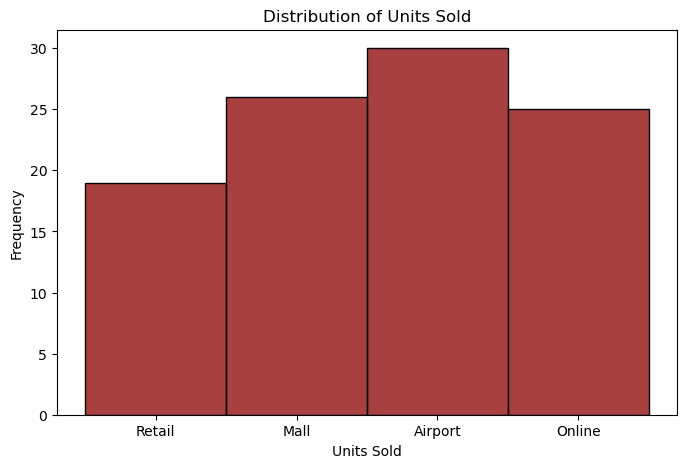

In [3]:
#Plot histogram of store sales volume
plt.figure(figsize=(8,5))
sns.histplot(data=stores, x="store_type", bins=25,  color="darkred")
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

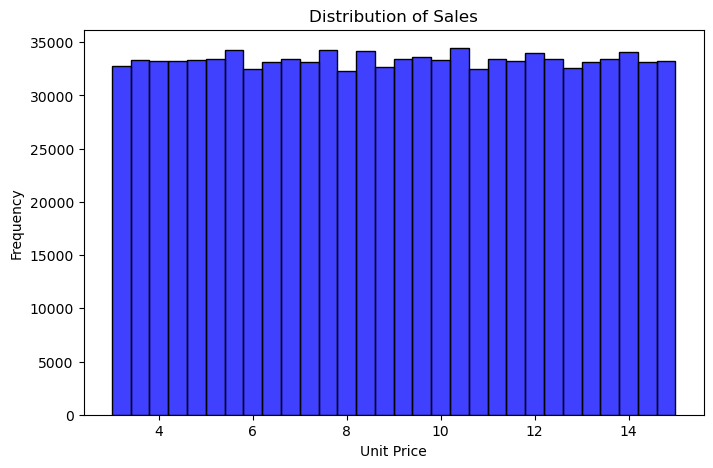

In [27]:
#  Plot histogram of sales
plt.figure(figsize=(8,5))
sns.histplot(data=sales, x="unit_price", bins=30,  color="blue")
plt.title("Distribution of Sales")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

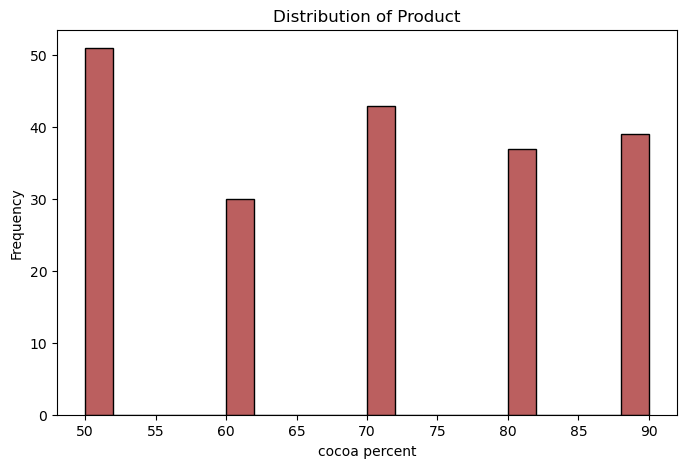

In [28]:
# Plot histogram of product prices
plt.figure(figsize=(8,5))
sns.histplot(data=products, x="cocoa_percent", bins=20,  color="brown")
plt.title("Distribution of Product")
plt.xlabel("cocoa percent")
plt.ylabel("Frequency")
plt.show()